In [1]:
import os
os.chdir('../..')

In [2]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
import kmedoids 
import chemiscope

from src.datasets import QM9Dataset
from src.features import get_features_xyz, get_raw_xyz_features
from src.non_euclidean import Grassmann, Riemann, PersistentHomology
from src.helper_functions import get_structures

2026-03-03 11:27:52.645 | INFO     | utils.file_ops:get_device:36 - Using Apple Silicon (MPS)


In [3]:
mol_ids = ["qm9_1237", "qm9_1244", "qm9_1246", "qm9_1248", "qm9_1474", "qm9_1476", "qm9_1478", "qm9_1486", "qm9_1447", "qm9_1449"]
qm9_loader = QM9Dataset(required_mol_ids=mol_ids)

qm9_loader.load()
rattle = 1.5
frames = qm9_loader.run_stress_test(mol_ids=mol_ids, max_rattle=rattle)
frames_rotated = qm9_loader.run_stress_test(mol_ids=mol_ids, rotated=True, max_rattle=rattle)

2026-03-03 11:27:54.146 | INFO     | src.datasets:load:69 - Loading QM9 from data/QM9/dataset_cleaned.csv...
2026-03-03 11:27:54.178 | INFO     | src.geometry:generate_stress_test:57 - Generating Grassmann Stress Test (Seed=40, Rotated=False, Max Rattle=1.5)...
2026-03-03 11:27:54.230 | INFO     | src.geometry:generate_stress_test:138 - Generated 210 frames. Failed molecules: 0
2026-03-03 11:27:54.247 | SUCCESS  | src.geometry:generate_stress_test:142 - Saved stress test to data/QM9/stress_test.xyz
2026-03-03 11:27:54.248 | INFO     | src.geometry:generate_stress_test:57 - Generating Grassmann Stress Test (Seed=40, Rotated=True, Max Rattle=1.5)...
2026-03-03 11:27:54.268 | INFO     | src.geometry:generate_stress_test:138 - Generated 210 frames. Failed molecules: 0
2026-03-03 11:27:54.282 | SUCCESS  | src.geometry:generate_stress_test:142 - Saved stress test to data/QM9/stress_test_rotated.xyz


In [4]:
print(f"Loaded {len(frames)} total frames.")

first_frame = frames[0]

print(first_frame.get_positions())

print(first_frame.info['mol_id'])
print(first_frame.info['smiles'])

Loaded 210 total frames.
[[-2.23869136e+00  1.17284150e+00 -1.50628536e-01]
 [-2.18580854e+00 -2.05362086e-01  2.11199383e-02]
 [-8.16122538e-01 -5.91546385e-01  5.27973086e-01]
 [ 2.14003108e-01 -1.32549071e-01 -5.11167931e-01]
 [ 1.55984030e+00 -5.24685078e-01 -1.02635725e-02]
 [ 1.80056810e+00 -1.68779018e+00  2.83362211e-01]
 [ 2.59011776e+00  5.68651946e-01  1.19159263e-01]
 [-2.76273015e+00  1.63706153e+00  5.37623333e-01]
 [-2.97176042e+00 -5.26490986e-01  7.42055047e-01]
 [-2.40399156e+00 -7.24614645e-01 -9.18317171e-01]
 [-6.23708209e-01 -1.19843440e-02  1.46754030e+00]
 [-7.77554176e-01 -1.67195748e+00  7.23975576e-01]
 [-2.28343044e-03 -7.31194841e-01 -1.44550394e+00]
 [ 1.12706277e-01  9.30257058e-01 -6.67700347e-01]
 [ 2.89637275e+00  1.00101876e+00 -8.35940170e-01]
 [ 3.49206784e+00  1.44851959e-01  5.88789586e-01]
 [ 2.11697424e+00  1.35349235e+00  7.75231984e-01]]
qm9_1237
[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]


In [5]:
ref_pos = frames[0].get_positions()
pert_pos = frames[1].get_positions()

distances = np.linalg.norm(pert_pos - ref_pos, axis=1)

print(f"Analysis for {frames[0].info['mol_id']}:")
print(f"Max displacement: {distances.max():.4f} Å")
print(f"Min displacement: {distances.min():.4f} Å")
print(f"Average displacement: {distances.mean():.4f} Å (Target was ~0.2)")

Analysis for qm9_1237:
Max displacement: 1.9738 Å
Min displacement: 0.4196 Å
Average displacement: 1.2503 Å (Target was ~0.2)


In [6]:
bond_lengths = []
for i in range(20):
    dist = frames[i].get_distance(0, 1)
    bond_lengths.append(dist)

print(f"Original Bond Length (approx): {bond_lengths[0]:.4f} Å")
print(f"Standard Deviation of bond length: {np.std(bond_lengths):.4f} Å")

Original Bond Length (approx): 1.3899 Å
Standard Deviation of bond length: 1.0125 Å


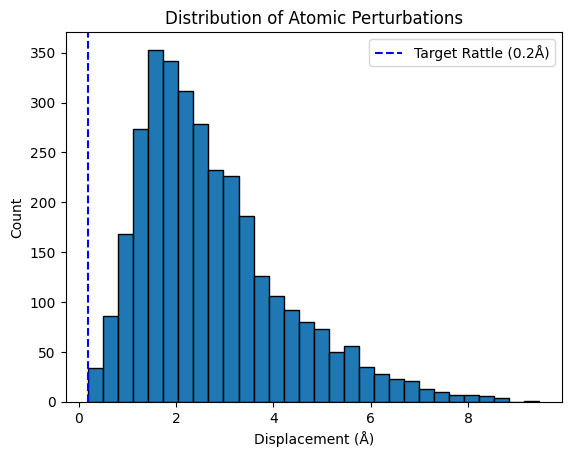

In [7]:
all_displacements = []

for m in range(0, 200, 20):
    ref_pos = frames[m].get_positions()
    for p in range(1, 20):
        pert_pos = frames[m + p].get_positions()
        diff = np.linalg.norm(pert_pos - ref_pos, axis=1)
        all_displacements.extend(diff)

plt.hist(all_displacements, bins=30, edgecolor='black')
plt.axvline(0.2, color='blue', linestyle='--', label='Target Rattle (0.2Å)')
plt.title("Distribution of Atomic Perturbations")
plt.xlabel("Displacement (Å)")
plt.ylabel("Count")
plt.legend()
plt.show()

# Clustering

In [8]:
def make_clustering(frames, rotational_invariant=False, dist_matrix=None, metric_name="euclidean"):
    """
    Unified clustering function handling both feature matrices and precomputed distance matrices.
    """
    true_labels = [f.info['mol_id'] for f in frames]
    smiles_list = [f.info.get('smiles', '') for f in frames]
    base_or_pertubated = [f.info.get('frame_type', '') for f in frames]

    unique_mol_ids = list(set(true_labels))
    n_clusters = len(unique_mol_ids)

    if dist_matrix is not None:
        print(f"Using precomputed {metric_name} distance matrix (Shape: {dist_matrix.shape})")
        
        clustering = kmedoids.KMedoids(n_clusters)
        cluster_labels = clustering.fit_predict(dist_matrix)
        
        tsne = TSNE(
            n_components=2, 
            metric='precomputed', 
            init='random', 
            random_state=42, 
            perplexity=30
        )
        X_tsne = tsne.fit_transform(dist_matrix)
        
        suffix = metric_name

    else:
        print("Using feature-based representation...")
        if rotational_invariant:
            X = get_features_xyz(frames)
            suffix = "invariant"
        else:
            X = get_raw_xyz_features(frames)
            suffix = "raw"
            
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(X)

        tsne = TSNE(
            n_components=2, 
            random_state=42, 
            perplexity=30, 
            init='pca'
        )
        X_tsne = tsne.fit_transform(X)

    ari_score = adjusted_rand_score(true_labels, cluster_labels)
    print(f"\nClustering Performance (Adjusted Rand Index) [{suffix}]: {ari_score:.4f}")

    analysis_df = pl.DataFrame({
        "cluster": cluster_labels,
        "true_mol_id": true_labels,
        "smiles": smiles_list
    })

    summary_table = (
        analysis_df.group_by("cluster")
        .agg([
            pl.col("true_mol_id").n_unique().alias("unique_mols"),
            pl.col("true_mol_id").unique().alias("mol_ids_in_cluster"),
            pl.col("smiles").first().alias("representative_smiles"),
            pl.len().alias("total_samples")
        ])
        .sort("cluster")
    )

    pl.Config.set_fmt_str_lengths(1000)
    pl.Config.set_tbl_rows(100)
    pl.Config.set_fmt_table_cell_list_len(50)
    print("\nCluster Composition Summary:")
    display(summary_table)

    structures, _ = get_structures(qm9_loader.df, mol_id_list=true_labels)
    structures = [s for s in structures for _ in range(21)]

    properties = {
        "t-SNE 1": X_tsne[:, 0],
        "t-SNE 2": X_tsne[:, 1],
        "Cluster": cluster_labels,
        "True Mol ID": true_labels,
        "SMILES": smiles_list,
        "Frame Type": base_or_pertubated
    }

    output_path = f"report/qm9/figures/grassmann/chemiscope_clustering_{suffix}.json.gz"

    chemiscope.write_input(
        output_path,
        properties=properties,
        structures=structures,
    )
    
    print(f"\nChemiscope file successfully saved to: {output_path}")

    return summary_table, output_path

In [9]:
summary_table_inv, output_path_inv = make_clustering(frames, rotational_invariant=True)

chemiscope.show_input(output_path_inv)

Using feature-based representation...

Clustering Performance (Adjusted Rand Index) [invariant]: 0.0467

Cluster Composition Summary:


cluster,unique_mols,mol_ids_in_cluster,representative_smiles,total_samples
i32,u32,list[str],str,u32
0,9,"[""qm9_1237"", ""qm9_1244"", ""qm9_1248"", ""qm9_1447"", ""qm9_1449"", ""qm9_1474"", ""qm9_1476"", ""qm9_1478"", ""qm9_1486""]","""[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",31
1,7,"[""qm9_1237"", ""qm9_1244"", ""qm9_1246"", ""qm9_1248"", ""qm9_1474"", ""qm9_1478"", ""qm9_1486""]","""[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",20
2,10,"[""qm9_1237"", ""qm9_1244"", ""qm9_1246"", ""qm9_1248"", ""qm9_1447"", ""qm9_1449"", ""qm9_1474"", ""qm9_1476"", ""qm9_1478"", ""qm9_1486""]","""[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",37
3,8,"[""qm9_1237"", ""qm9_1244"", ""qm9_1246"", ""qm9_1248"", ""qm9_1474"", ""qm9_1476"", ""qm9_1478"", ""qm9_1486""]","""[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",27
4,2,"[""qm9_1447"", ""qm9_1449""]","""[H]C(=O)O[C@]([H])(C([H])([H])[H])C([H])([H])C([H])([H])[H]""",5
5,9,"[""qm9_1237"", ""qm9_1244"", ""qm9_1246"", ""qm9_1248"", ""qm9_1449"", ""qm9_1474"", ""qm9_1476"", ""qm9_1478"", ""qm9_1486""]","""[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",27
6,6,"[""qm9_1244"", ""qm9_1246"", ""qm9_1248"", ""qm9_1474"", ""qm9_1478"", ""qm9_1486""]","""[H]C([H])([H])C(=O)OC([H])([H])C([H])([H])C([H])([H])[H]""",14
7,6,"[""qm9_1237"", ""qm9_1246"", ""qm9_1248"", ""qm9_1449"", ""qm9_1476"", ""qm9_1486""]","""[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",17
8,9,"[""qm9_1237"", ""qm9_1244"", ""qm9_1246"", ""qm9_1248"", ""qm9_1449"", ""qm9_1474"", ""qm9_1476"", ""qm9_1478"", ""qm9_1486""]","""[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",18



Chemiscope file successfully saved to: report/qm9/figures/grassmann/chemiscope_clustering_invariant.json.gz


<ChemiscopeWidget(meta={'name': 'chemiscope_clustering_invariant'}, structures=[{'size': 17, 'data': 'structur…

In [10]:
summary_table, output_path = make_clustering(frames, rotational_invariant=False)

chemiscope.show_input(output_path)

Using feature-based representation...

Clustering Performance (Adjusted Rand Index) [raw]: 0.8672

Cluster Composition Summary:


cluster,unique_mols,mol_ids_in_cluster,representative_smiles,total_samples
i32,u32,list[str],str,u32
0,1,"[""qm9_1244""]","""[H]C([H])([H])C(=O)OC([H])([H])C([H])([H])C([H])([H])[H]""",21
1,1,"[""qm9_1237""]","""[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",21
2,1,"[""qm9_1449""]","""[H]C(=O)C([H])([H])[C@@]([H])(OC([H])([H])[H])C([H])([H])[H]""",21
3,2,"[""qm9_1246"", ""qm9_1476""]","""[H]C([H])([H])C(=O)C([H])([H])OC([H])([H])C([H])([H])[H]""",22
4,1,"[""qm9_1248""]","""[H]C([H])([H])OC([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",5
5,1,"[""qm9_1447""]","""[H]C(=O)O[C@]([H])(C([H])([H])[H])C([H])([H])C([H])([H])[H]""",21
6,1,"[""qm9_1474""]","""[H]C([H])([H])OC([H])([H])C(=O)C([H])([H])C([H])([H])[H]""",21
7,1,"[""qm9_1486""]","""[H]C([H])([H])C([H])([H])OC(=O)C([H])([H])C([H])([H])[H]""",21
8,1,"[""qm9_1248""]","""[H]C([H])([H])OC([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",16



Chemiscope file successfully saved to: report/qm9/figures/grassmann/chemiscope_clustering_raw.json.gz


<ChemiscopeWidget(meta={'name': 'chemiscope_clustering_raw'}, structures=[{'size': 17, 'data': 'structure-0'},…

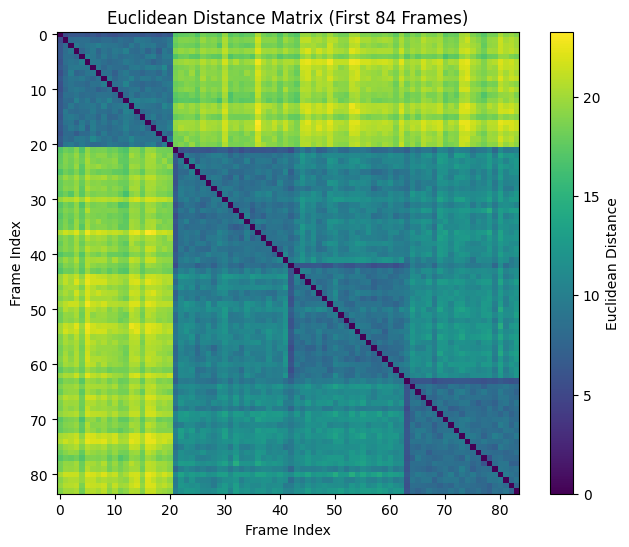

Using precomputed euclidean_precomputed distance matrix (Shape: (210, 210))

Clustering Performance (Adjusted Rand Index) [euclidean_precomputed]: 1.0000

Cluster Composition Summary:


cluster,unique_mols,mol_ids_in_cluster,representative_smiles,total_samples
u64,u32,list[str],str,u32
0,1,"[""qm9_1246""]","""[H]C([H])([H])C(=O)C([H])([H])OC([H])([H])C([H])([H])[H]""",21
1,1,"[""qm9_1449""]","""[H]C(=O)C([H])([H])[C@@]([H])(OC([H])([H])[H])C([H])([H])[H]""",21
2,1,"[""qm9_1237""]","""[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",21
3,1,"[""qm9_1478""]","""[H]C([H])([H])OC(=O)C([H])([H])C([H])([H])C([H])([H])[H]""",21
4,1,"[""qm9_1447""]","""[H]C(=O)O[C@]([H])(C([H])([H])[H])C([H])([H])C([H])([H])[H]""",21
5,1,"[""qm9_1486""]","""[H]C([H])([H])C([H])([H])OC(=O)C([H])([H])C([H])([H])[H]""",21
6,1,"[""qm9_1476""]","""[H]OC([H])([H])C(=O)C([H])([H])C([H])([H])C([H])([H])[H]""",21
7,1,"[""qm9_1244""]","""[H]C([H])([H])C(=O)OC([H])([H])C([H])([H])C([H])([H])[H]""",21
8,1,"[""qm9_1248""]","""[H]C([H])([H])OC([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",21



Chemiscope file successfully saved to: report/qm9/figures/grassmann/chemiscope_clustering_euclidean_precomputed.json.gz


<ChemiscopeWidget(meta={'name': 'chemiscope_clustering_euclidean_precomputed'}, structures=[{'size': 17, 'data…

In [11]:
from sklearn.metrics import pairwise_distances

X_euclidean = get_raw_xyz_features(frames)
dist_matrix_euclidean = pairwise_distances(X_euclidean, metric='euclidean')

plt.figure(figsize=(8, 6))
plt.imshow(dist_matrix_euclidean[:84, :84], cmap='viridis')
plt.colorbar(label='Euclidean Distance')
plt.title("Euclidean Distance Matrix (First 84 Frames)")
plt.xlabel("Frame Index")
plt.ylabel("Frame Index")
plt.show()

summary_eucl, path_eucl = make_clustering(
    frames, 
    dist_matrix=dist_matrix_euclidean, 
    metric_name="euclidean_precomputed",
)

chemiscope.show_input(path_eucl)

"qm9_1237", "qm9_1244", "qm9_1246", "qm9_1248", "qm9_1474", "qm9_1476", "qm9_1478", "qm9_1486", "qm9_1447", "qm9_1449"]

# Grassmann Clustering

2026-03-03 11:27:56.185 | INFO     | src.non_euclidean:distance_matrix:209 - Computing Grassmann distance matrix for 210 frames (k=3, method='qr').
2026-03-03 11:27:57.829 | DEBUG    | src.non_euclidean:distance_matrix:221 - Finished Grassmann distance matrix computation.


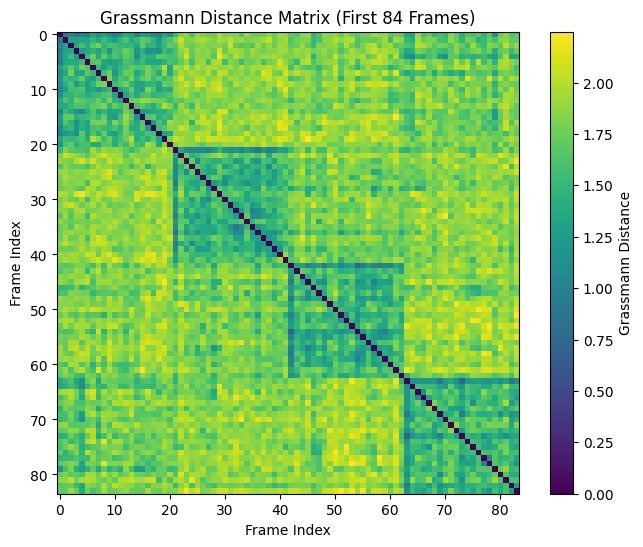

In [12]:
dist_matrix_grassmann = Grassmann.distance_matrix(frames, method='qr')

plt.figure(figsize=(8, 6))
plt.imshow(dist_matrix_grassmann[:84, :84], cmap='viridis')
plt.colorbar(label='Grassmann Distance')
plt.title("Grassmann Distance Matrix (First 84 Frames)")
plt.xlabel("Frame Index")
plt.ylabel("Frame Index")
plt.show()

In [13]:
summary_grassmann, path_grassmann = make_clustering(
    frames, 
    dist_matrix=dist_matrix_grassmann, 
    metric_name="grassmann"
)

chemiscope.show_input(path_grassmann)

Using precomputed grassmann distance matrix (Shape: (210, 210))

Clustering Performance (Adjusted Rand Index) [grassmann]: 0.9385

Cluster Composition Summary:


cluster,unique_mols,mol_ids_in_cluster,representative_smiles,total_samples
u64,u32,list[str],str,u32
0,1,"[""qm9_1449""]","""[H]C(=O)C([H])([H])[C@@]([H])(OC([H])([H])[H])C([H])([H])[H]""",21
1,2,"[""qm9_1244"", ""qm9_1486""]","""[H]C([H])([H])C(=O)OC([H])([H])C([H])([H])C([H])([H])[H]""",22
2,2,"[""qm9_1476"", ""qm9_1478""]","""[H]OC([H])([H])C(=O)C([H])([H])C([H])([H])C([H])([H])[H]""",23
3,1,"[""qm9_1447""]","""[H]C(=O)O[C@]([H])(C([H])([H])[H])C([H])([H])C([H])([H])[H]""",21
4,1,"[""qm9_1246""]","""[H]C([H])([H])C(=O)C([H])([H])OC([H])([H])C([H])([H])[H]""",21
5,1,"[""qm9_1244""]","""[H]C([H])([H])C(=O)OC([H])([H])C([H])([H])C([H])([H])[H]""",20
6,2,"[""qm9_1476"", ""qm9_1478""]","""[H]OC([H])([H])C(=O)C([H])([H])C([H])([H])C([H])([H])[H]""",19
7,1,"[""qm9_1474""]","""[H]C([H])([H])OC([H])([H])C(=O)C([H])([H])C([H])([H])[H]""",21
8,1,"[""qm9_1248""]","""[H]C([H])([H])OC([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",20



Chemiscope file successfully saved to: report/qm9/figures/grassmann/chemiscope_clustering_grassmann.json.gz


<ChemiscopeWidget(meta={'name': 'chemiscope_clustering_grassmann'}, structures=[{'size': 17, 'data': 'structur…

# Riemann Clustering

In [14]:
dist_matrix_eucliean_riemann = Riemann.distance_matrix(frames, metric_type='log-euclidean')
dist_matrix_affine_riemann = Riemann.distance_matrix(frames, metric_type='affine-invariant')

summary_riemann, path_riemann = make_clustering(
    frames, 
    dist_matrix=dist_matrix_eucliean_riemann, 
    metric_name="log-euclidean"
)

chemiscope.show_input(path_riemann)

summary_affine_riemann, path_affine_riemann = make_clustering(
    frames,
    dist_matrix=dist_matrix_affine_riemann,
    metric_name="affine-invariant"
)


2026-03-03 11:27:58.352 | INFO     | src.non_euclidean:distance_matrix:253 - Computing Riemannian distance matrix for 210 frames (metric_type='log-euclidean').
2026-03-03 11:27:58.909 | SUCCESS  | src.non_euclidean:distance_matrix:276 - Finished Riemannian distance matrix computation.
2026-03-03 11:27:58.909 | INFO     | src.non_euclidean:distance_matrix:253 - Computing Riemannian distance matrix for 210 frames (metric_type='affine-invariant').
2026-03-03 11:27:59.203 | SUCCESS  | src.non_euclidean:distance_matrix:276 - Finished Riemannian distance matrix computation.


Using precomputed log-euclidean distance matrix (Shape: (210, 210))

Clustering Performance (Adjusted Rand Index) [log-euclidean]: 0.1698

Cluster Composition Summary:


cluster,unique_mols,mol_ids_in_cluster,representative_smiles,total_samples
u64,u32,list[str],str,u32
0,1,"[""qm9_1447""]","""[H]C(=O)O[C@]([H])(C([H])([H])[H])C([H])([H])C([H])([H])[H]""",18
1,6,"[""qm9_1237"", ""qm9_1244"", ""qm9_1474"", ""qm9_1476"", ""qm9_1478"", ""qm9_1486""]","""[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",23
2,7,"[""qm9_1237"", ""qm9_1244"", ""qm9_1246"", ""qm9_1449"", ""qm9_1476"", ""qm9_1478"", ""qm9_1486""]","""[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",25
3,6,"[""qm9_1237"", ""qm9_1244"", ""qm9_1447"", ""qm9_1476"", ""qm9_1478"", ""qm9_1486""]","""[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",16
4,8,"[""qm9_1237"", ""qm9_1244"", ""qm9_1246"", ""qm9_1248"", ""qm9_1474"", ""qm9_1476"", ""qm9_1478"", ""qm9_1486""]","""[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",24
5,7,"[""qm9_1237"", ""qm9_1244"", ""qm9_1246"", ""qm9_1248"", ""qm9_1474"", ""qm9_1476"", ""qm9_1486""]","""[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",19
6,7,"[""qm9_1237"", ""qm9_1244"", ""qm9_1246"", ""qm9_1474"", ""qm9_1476"", ""qm9_1478"", ""qm9_1486""]","""[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",12
7,6,"[""qm9_1244"", ""qm9_1246"", ""qm9_1248"", ""qm9_1474"", ""qm9_1478"", ""qm9_1486""]","""[H]C([H])([H])C(=O)OC([H])([H])C([H])([H])C([H])([H])[H]""",19
8,8,"[""qm9_1237"", ""qm9_1244"", ""qm9_1246"", ""qm9_1447"", ""qm9_1449"", ""qm9_1476"", ""qm9_1478"", ""qm9_1486""]","""[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",26



Chemiscope file successfully saved to: report/qm9/figures/grassmann/chemiscope_clustering_log-euclidean.json.gz
Using precomputed affine-invariant distance matrix (Shape: (210, 210))

Clustering Performance (Adjusted Rand Index) [affine-invariant]: 0.1930

Cluster Composition Summary:


cluster,unique_mols,mol_ids_in_cluster,representative_smiles,total_samples
u64,u32,list[str],str,u32
0,7,"[""qm9_1237"", ""qm9_1244"", ""qm9_1248"", ""qm9_1449"", ""qm9_1476"", ""qm9_1478"", ""qm9_1486""]","""[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",26
1,2,"[""qm9_1246"", ""qm9_1474""]","""[H]C([H])([H])C(=O)C([H])([H])OC([H])([H])C([H])([H])[H]""",9
2,7,"[""qm9_1237"", ""qm9_1244"", ""qm9_1246"", ""qm9_1449"", ""qm9_1476"", ""qm9_1478"", ""qm9_1486""]","""[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",21
3,8,"[""qm9_1237"", ""qm9_1244"", ""qm9_1246"", ""qm9_1449"", ""qm9_1474"", ""qm9_1476"", ""qm9_1478"", ""qm9_1486""]","""[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",29
4,7,"[""qm9_1237"", ""qm9_1244"", ""qm9_1248"", ""qm9_1447"", ""qm9_1449"", ""qm9_1478"", ""qm9_1486""]","""[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",19
5,5,"[""qm9_1244"", ""qm9_1447"", ""qm9_1449"", ""qm9_1476"", ""qm9_1478""]","""[H]C([H])([H])C(=O)OC([H])([H])C([H])([H])C([H])([H])[H]""",25
6,7,"[""qm9_1237"", ""qm9_1244"", ""qm9_1248"", ""qm9_1474"", ""qm9_1476"", ""qm9_1478"", ""qm9_1486""]","""[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",30
7,8,"[""qm9_1237"", ""qm9_1246"", ""qm9_1248"", ""qm9_1449"", ""qm9_1474"", ""qm9_1476"", ""qm9_1478"", ""qm9_1486""]","""[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",22
8,3,"[""qm9_1246"", ""qm9_1474"", ""qm9_1476""]","""[H]C([H])([H])C(=O)C([H])([H])OC([H])([H])C([H])([H])[H]""",12



Chemiscope file successfully saved to: report/qm9/figures/grassmann/chemiscope_clustering_affine-invariant.json.gz


# Persistent Homology

2026-03-03 11:32:12.512 | INFO     | src.non_euclidean:distance_matrix:133 - Computing persistent homology distance matrix for 210 frames (backend='ripser', metric='bottleneck', max_homology_dim=2, dims=(0, 1, 2)).
2026-03-03 11:32:12.513 | INFO     | src.non_euclidean:compute_persistence_diagrams:79 - Computing persistence diagrams for 210 frames (backend='ripser', max_homology_dim=2).
2026-03-03 11:32:12.619 | DEBUG    | src.non_euclidean:compute_persistence_diagrams:92 - Finished persistence diagram computation.
Computing Persistence Diagram Distance Matrix:   0%|          | 0/210 [00:00<?, ?it/s]/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/persim/bottleneck.py:55: UserWarning: dgm1 has points with non-finite death times;ignoring those points
  warnings.warn(
/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-pac

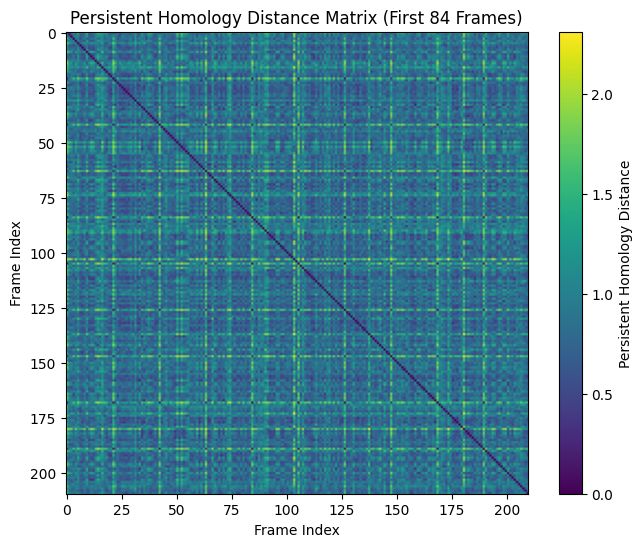

In [17]:
persistent_dist_matrix = PersistentHomology.distance_matrix(frames, metric="bottleneck")

plt.figure(figsize=(8, 6))
plt.imshow(persistent_dist_matrix, cmap='viridis')
plt.colorbar(label='Persistent Homology Distance')
plt.title("Persistent Homology Distance Matrix (First 84 Frames)")
plt.xlabel("Frame Index")
plt.ylabel("Frame Index")
plt.show()

In [18]:
summary_persistent_homology, path_persistent_homology = make_clustering(
    frames, 
    dist_matrix=persistent_dist_matrix,
)

chemiscope.show_input(path_persistent_homology)

Using precomputed euclidean distance matrix (Shape: (210, 210))

Clustering Performance (Adjusted Rand Index) [euclidean]: -0.0080

Cluster Composition Summary:


cluster,unique_mols,mol_ids_in_cluster,representative_smiles,total_samples
u64,u32,list[str],str,u32
0,9,"[""qm9_1237"", ""qm9_1244"", ""qm9_1246"", ""qm9_1248"", ""qm9_1447"", ""qm9_1449"", ""qm9_1476"", ""qm9_1478"", ""qm9_1486""]","""[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",19
1,9,"[""qm9_1237"", ""qm9_1244"", ""qm9_1246"", ""qm9_1248"", ""qm9_1447"", ""qm9_1449"", ""qm9_1474"", ""qm9_1476"", ""qm9_1486""]","""[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",23
2,10,"[""qm9_1237"", ""qm9_1244"", ""qm9_1246"", ""qm9_1248"", ""qm9_1447"", ""qm9_1449"", ""qm9_1474"", ""qm9_1476"", ""qm9_1478"", ""qm9_1486""]","""[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",30
3,10,"[""qm9_1237"", ""qm9_1244"", ""qm9_1246"", ""qm9_1248"", ""qm9_1447"", ""qm9_1449"", ""qm9_1474"", ""qm9_1476"", ""qm9_1478"", ""qm9_1486""]","""[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",26
4,10,"[""qm9_1237"", ""qm9_1244"", ""qm9_1246"", ""qm9_1248"", ""qm9_1447"", ""qm9_1449"", ""qm9_1474"", ""qm9_1476"", ""qm9_1478"", ""qm9_1486""]","""[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",28
5,10,"[""qm9_1237"", ""qm9_1244"", ""qm9_1246"", ""qm9_1248"", ""qm9_1447"", ""qm9_1449"", ""qm9_1474"", ""qm9_1476"", ""qm9_1478"", ""qm9_1486""]","""[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",10
6,10,"[""qm9_1237"", ""qm9_1244"", ""qm9_1246"", ""qm9_1248"", ""qm9_1447"", ""qm9_1449"", ""qm9_1474"", ""qm9_1476"", ""qm9_1478"", ""qm9_1486""]","""[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",31
7,8,"[""qm9_1237"", ""qm9_1244"", ""qm9_1248"", ""qm9_1447"", ""qm9_1449"", ""qm9_1474"", ""qm9_1478"", ""qm9_1486""]","""[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",12
8,9,"[""qm9_1237"", ""qm9_1246"", ""qm9_1248"", ""qm9_1447"", ""qm9_1449"", ""qm9_1474"", ""qm9_1476"", ""qm9_1478"", ""qm9_1486""]","""[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",20



Chemiscope file successfully saved to: report/qm9/figures/grassmann/chemiscope_clustering_euclidean.json.gz


<ChemiscopeWidget(meta={'name': 'chemiscope_clustering_euclidean'}, structures=[{'size': 17, 'data': 'structur…